# Read Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


# Clean Data

In [3]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges            str
churn                   str
dtype: object

In [4]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)
df.totalcharges.isna().sum()

np.int64(0)

In [5]:
df.churn = (df.churn == 'Yes').astype(int)
df.head().T

,0,1,2,3,4
customerid,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
seniorcitizen,0,0,0,0,0
partner,Yes,No,No,No,No
dependents,No,No,No,No,No
tenure,1,34,2,45,2
phoneservice,No,Yes,Yes,No,Yes
multiplelines,No phone service,No,No,No phone service,No
internetservice,DSL,DSL,DSL,DSL,Fiber optic
onlinesecurity,No,Yes,Yes,Yes,No


# Set up the validation framework

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [8]:
len(df),len(df_train), len(df_val), len(df_test)

(7043, 4225, 1409, 1409)

In [9]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [10]:
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

In [11]:
df_train = df_train.drop(columns=['churn'])
df_val = df_val.drop(columns=['churn'])
df_test = df_test.drop(columns=['churn'])

# Exploratory Data Analysis

In [12]:
df_full_train.isnull().sum().sort_values(ascending=False)

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [13]:
df_full_train.churn.value_counts(normalize=True)

churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64

In [14]:
numeric = ['tenure', 'monthlycharges', 'totalcharges']
categorical = ['gender', 'partner', 'dependents', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod']

In [15]:
df_full_train[categorical].nunique().sort_values(ascending=False)

paymentmethod       4
internetservice     3
onlinesecurity      3
deviceprotection    3
techsupport         3
onlinebackup        3
multiplelines       3
streamingtv         3
streamingmovies     3
contract            3
dependents          2
phoneservice        2
gender              2
partner             2
paperlessbilling    2
dtype: int64

<Axes: xlabel='contract', ylabel='churn'>

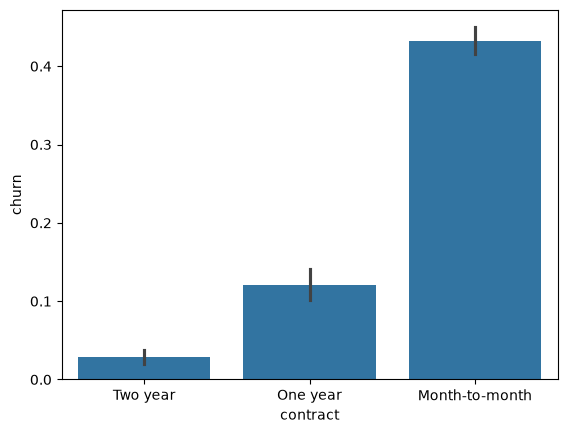

In [16]:
sns.barplot(x = df_full_train['contract'], y = df_full_train['churn'])

<Axes: xlabel='gender', ylabel='churn'>

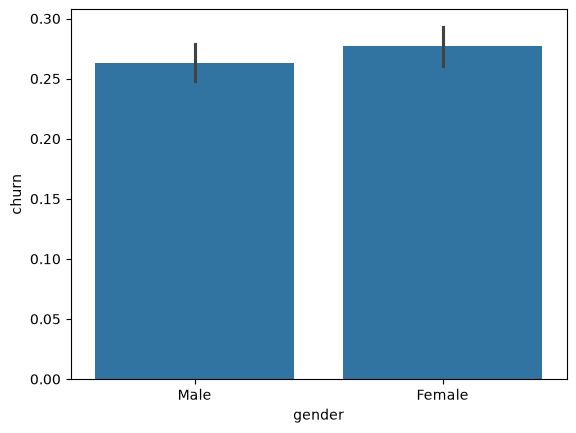

In [17]:
sns.barplot(x = df_full_train['gender'], y = df_full_train['churn'])

<Axes: xlabel='paperlessbilling', ylabel='churn'>

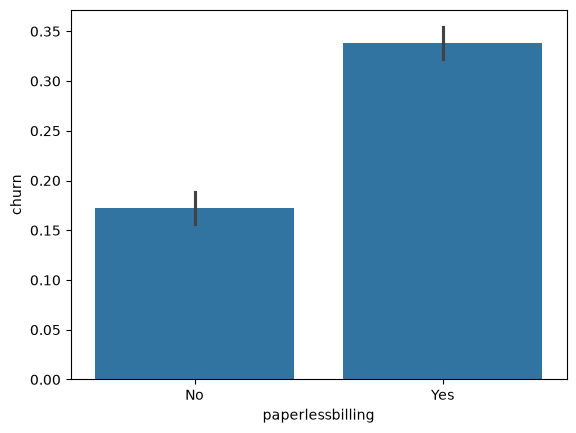

In [18]:
sns.barplot(x = df_full_train['paperlessbilling'], y = df_full_train['churn'])

<Axes: xlabel='seniorcitizen', ylabel='churn'>

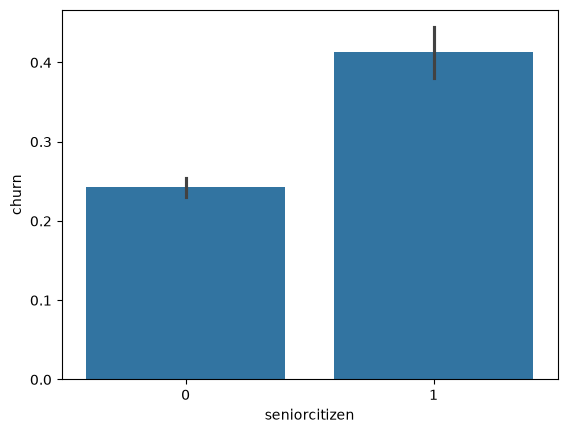

In [19]:
sns.barplot(x = df_full_train['seniorcitizen'], y = df_full_train['churn'])

<Axes: xlabel='multiplelines', ylabel='churn'>

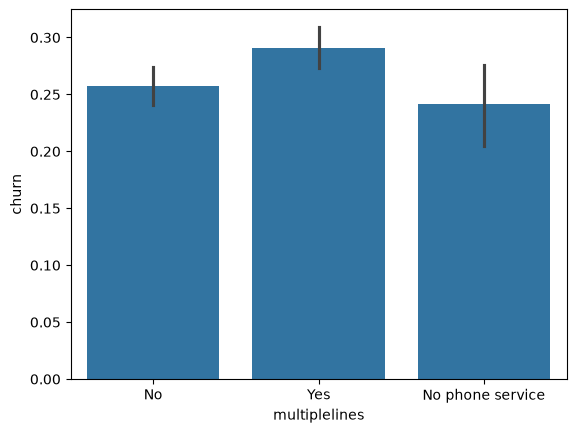

In [20]:
sns.barplot(x = df_full_train['multiplelines'], y = df_full_train['churn'])

<Axes: xlabel='partner', ylabel='churn'>

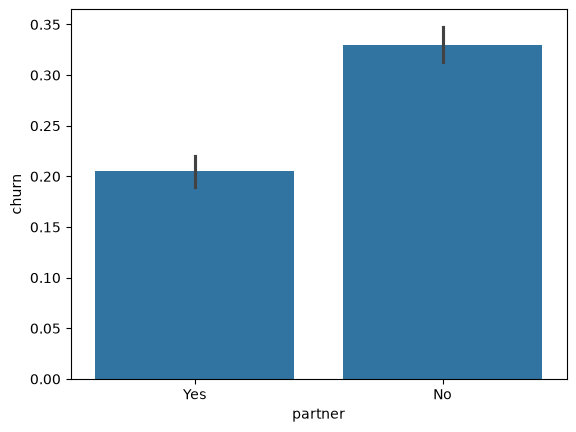

In [21]:
sns.barplot(x = df_full_train['partner'], y = df_full_train['churn'])

<Axes: xlabel='dependents', ylabel='churn'>

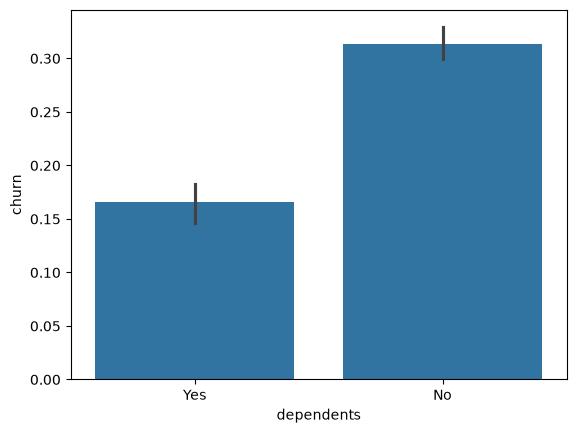

In [22]:
sns.barplot(x = df_full_train['dependents'], y = df_full_train['churn'])

<Axes: xlabel='phoneservice', ylabel='churn'>

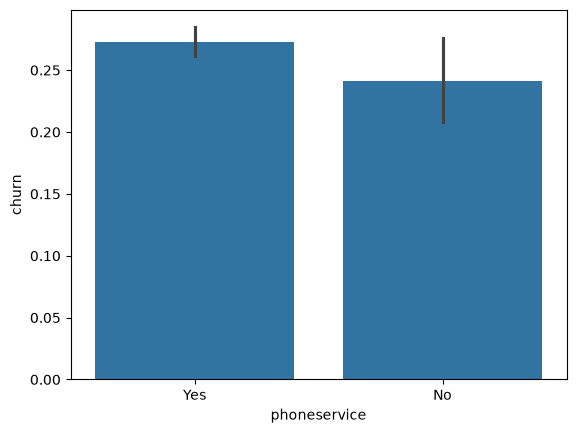

In [23]:
sns.barplot(x = df_full_train['phoneservice'], y = df_full_train['churn'])

In [24]:
for c in categorical:
    print(c)
    df_group = df_full_train.groupby(c).churn.aggregate(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - df_full_train.churn.mean()
    df_group['ratio'] = df_group['mean'] / df_full_train.churn.mean()
    print(df_group)

gender
            mean  count      diff     ratio
gender                                     
Female  0.276824   2796  0.006856  1.025396
Male    0.263214   2838 -0.006755  0.974980
partner
             mean  count      diff     ratio
partner                                     
No       0.329809   2932  0.059841  1.221659
Yes      0.205033   2702 -0.064935  0.759472
dependents
                mean  count      diff     ratio
dependents                                     
No          0.313760   3968  0.043792  1.162212
Yes         0.165666   1666 -0.104302  0.613651
phoneservice
                  mean  count      diff     ratio
phoneservice                                     
No            0.241316    547 -0.028652  0.893870
Yes           0.273049   5087  0.003081  1.011412
multiplelines
                      mean  count      diff     ratio
multiplelines                                        
No                0.257407   2700 -0.012561  0.953474
No phone service  0.241316    547 -0.

In [25]:
from sklearn.metrics import mutual_info_score
def mutual_info_score_series(series):
    return mutual_info_score(series, df_full_train.churn)
df_full_train[categorical].apply(mutual_info_score_series).sort_values(ascending=False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

In [26]:
df_full_train[numeric].corrwith(df_full_train.churn)

tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

# One-hot encoding

In [27]:
from sklearn.feature_extraction import DictVectorizer

In [28]:
dv = DictVectorizer(sparse=False)

In [29]:
train_dict = df_train[categorical + numeric].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)
val_dict = df_val[categorical + numeric].to_dict(orient='records')
X_val = dv.transform(val_dict)
test_dict = df_test[categorical + numeric].to_dict(orient='records')
X_test = dv.transform(test_dict)

# Training logistic regression 

In [30]:
from sklearn.linear_model import LogisticRegression

In [31]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalt

In [32]:
model.coef_

array([[ 6.18960251e-01, -6.01215676e-02, -6.81344624e-01,
        -6.08963638e-03, -1.16416304e-01,  5.29732334e-02,
        -1.02687872e-01, -7.27913020e-02, -4.22167165e-02,
        -8.02892244e-02, -3.82273348e-01,  3.62455279e-01,
        -1.02687872e-01,  2.54423766e-03, -2.51193171e-01,
         1.37725412e-01, -9.03818189e-03,  5.76184417e-02,
        -1.02687872e-01, -7.74365103e-02,  2.18571666e-01,
        -1.02687872e-01, -2.38389735e-01, -2.50878912e-01,
         1.28372972e-01, -1.27245649e-01,  4.73970847e-03,
        -1.00495527e-01, -4.83290602e-02,  7.31033974e-02,
        -4.67847511e-02,  1.37725412e-01, -2.60231353e-01,
        -1.02727165e-01, -1.02687872e-01,  8.29090959e-02,
        -6.44700076e-02, -1.02687872e-01,  4.46519390e-02,
         1.78419982e-01, -1.02687872e-01, -1.98238051e-01,
        -6.65473676e-02,  3.77904997e-04]])

In [33]:
model.intercept_[0]

np.float64(-0.12250594083219997)

In [34]:
y_pred =model.predict_proba(X_val)[:,1]

In [35]:
churn_decision = (y_pred >= 0.5)

In [36]:
(y_val == churn_decision).mean()

np.float64(0.7998580553584103)

In [38]:
dict(zip(dv.get_feature_names_out(), np.exp(model.coef_[0].round(3))))

{'contract=Month-to-month': np.float64(1.8570700429587728),
 'contract=One year': np.float64(0.9417645335842487),
 'contract=Two year': np.float64(0.5061106285973052),
 'dependents=No': np.float64(0.9940179640539353),
 'dependents=Yes': np.float64(0.8904752232974726),
 'deviceprotection=No': np.float64(1.054429645119356),
 'deviceprotection=No internet service': np.float64(0.9021269734815165),
 'deviceprotection=Yes': np.float64(0.9296008300257927),
 'gender=Female': np.float64(0.9588697805724845),
 'gender=Male': np.float64(0.9231163463866358),
 'internetservice=DSL': np.float64(0.6824950532053901),
 'internetservice=Fiber optic': np.float64(1.4361989419603518),
 'internetservice=No': np.float64(0.9021269734815165),
 'monthlycharges': np.float64(1.003004504503377),
 'multiplelines=No': np.float64(0.7780223715589573),
 'multiplelines=No phone service': np.float64(1.1479755502741786),
 'multiplelines=Yes': np.float64(0.9910403787728836),
 'onlinebackup=No': np.float64(1.0597149957102876

# Using the model

In [40]:
dict_full_train = df_full_train[categorical + numeric].to_dict(orient='records')
dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dict_full_train)
y_full_train = df_full_train.churn.values
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_full_train, y_full_train)

,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalt

In [41]:
X_test = dv.transform(test_dict)
y_pred = model.predict_proba(X_test)[:,1]
churn_decision = (y_pred >= 0.5)
(y_test == churn_decision).mean()

np.float64(0.8076650106458482)

In [47]:
customer = test_dict[10]
customer

{'gender': 'Male',
 'partner': 'Yes',
 'dependents': 'Yes',
 'phoneservice': 'Yes',
 'multiplelines': 'No',
 'internetservice': 'Fiber optic',
 'onlinesecurity': 'No',
 'onlinebackup': 'Yes',
 'deviceprotection': 'No',
 'techsupport': 'No',
 'streamingtv': 'Yes',
 'streamingmovies': 'Yes',
 'contract': 'Month-to-month',
 'paperlessbilling': 'Yes',
 'paymentmethod': 'Mailed check',
 'tenure': 32,
 'monthlycharges': 93.95,
 'totalcharges': 2861.45}

In [49]:
customer_churn_probability = model.predict_proba(dv.transform([customer]))[0,1]
customer_churn_probability

np.float64(0.447273704970898)